In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import jax
import seaborn as sns
import glob
import pandas as pd



In [4]:
# prepare SC matrix, extract wLRE and wFFI and prepare the J_i, nothing with FC
folder_read = '/Users/lin/Documents/Bachelor thesis /E_I tuning model/'
fc_pred = np.load("/Users/lin/Documents/Bachelor thesis /FC_allsubj_allparcellations_Hagmann.npy", allow_pickle = True).item()

J_i_all = {}
SC_all = {}
labels_all = {}
wLRE = {}
wFFI = {}

path = '/Users/lin/Documents/Bachelor thesis /SC_matrices'
# print(os.listdir(folder_read))
for folder_metric in os.listdir(folder_read):
    if folder_metric[0] != '.': 
        J_i_all[folder_metric] = []
        SC_all[folder_metric] = []
        labels_all[folder_metric] = []
        wLRE[folder_metric] = []
        wFFI[folder_metric] = []
        print(folder_metric)
        SC_curr = np.load(path + '/' + folder_metric + '/' + folder_metric + '_allsubj_Hagmann.npy', allow_pickle=True).item()
        SC_all[folder_metric] = SC_curr
        
        k = 0
        for file_curr in os.listdir(folder_read + folder_metric):
            if file_curr[0]!= '.':
                # print(path + folder_metric)
                data_curr = np.load(folder_read + folder_metric + '/' + file_curr, allow_pickle = True).item()
                wFFI[folder_metric].append(data_curr['wFFI'].flatten())
                wLRE[folder_metric].append(data_curr['wLRE'].flatten())
                J_i_all[folder_metric].append(data_curr['J_i'])
                idx_label = file_curr.rfind('_')
                labels_all[folder_metric].append(file_curr[idx_label+1:idx_label+5]) 
        print(len(wLRE[folder_metric][2]))       
# print(labels_all)



density
6889
numb
6889
gFA
6889
ADC
6889
(83,)
(6889,)


In [5]:
# compute SC and FC matrix for eigenvectors and degree 
deg_all_SC = {} 
eig_all_SC = {}

for folder_metric in os.listdir(folder_read):
    if folder_metric[0] != '.':
        deg_all_SC[folder_metric] = []  
        eig_all_SC[folder_metric] = []                
        for idx in SC_all[folder_metric].keys():
            if SC_all[folder_metric][idx] is not None:
                sum = [0] * 83
                for i in range(83):
                    sum[i] = np.sum(SC_all[folder_metric][idx][83][i])
                deg_all_SC[folder_metric].append(sum)
            else:
                deg_all_SC[folder_metric].append([0] * 83)
        
        proband = list(SC_all[folder_metric].keys())
                # print(len(SC_all[folder_metric]))
        eig_vec = [0] * 83
        for j in range(len(proband)):
            ew, ev = np.linalg.eig(SC_all[folder_metric][proband[j]][83])
            principal_eig_vec = ev[:, -1] 
            eig_all_SC[folder_metric].append(principal_eig_vec)
            
deg_all_FC = []
eig_all_FC = []
FC_all = []

for idx in fc_pred.keys():
    eig_vec = [0] * 83
    sum = [0] * 83
    for i in range(83):
        sum[i] = np.sum(fc_pred[idx][83][i])
        # eig_vec[i] = np.linalg.eig(fc_pred[idx][83])
    ew, ev = np.linalg.eig(fc_pred[idx][83])
    principal_eig_vec = ev[:, -1] 
    
    eig_all_FC.append(principal_eig_vec)
    deg_all_FC.append(sum)
    FC_all.append(fc_pred[idx][83].flatten())
FC_all = np.array(FC_all)
    
print(FC_all.shape)


(54, 6889)


In [7]:
# Computing full FC matrix with SC matrix for all metrics

FC_SC = {}

for folder_metric in os.listdir(folder_read):
    if folder_metric[0] != '.':
        FC_SC[folder_metric] = []
        for idx in fc_pred.keys():
            fc_vec = fc_pred[idx][83].flatten()
            sc_vec = SC_all[folder_metric][idx][83].flatten()
            FC_SC[folder_metric].append(np.concatenate([fc_vec, sc_vec]))

all_data = {
    "J_i": J_i_all,
    "wLRE": wLRE, 
    "wFFI": wFFI, 
    "SC_deg": deg_all_SC, 
    "SC_eig": eig_all_SC, 
    "FC_SC": FC_SC
}

In [36]:
# SGD Classifier for all metrics 

import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

losses = ['hinge', 'perceptron', 'modified_huber', 'log_loss']
score_all_SGD = {}
nsplits = 100
for data_name, data in all_data.items():
    score_all_SGD[data_name] = {}
    deg_all = data
    metrics_all = list(deg_all.keys())
    
    for metric_curr in deg_all.keys():
        score_all_SGD[data_name][metric_curr] = {}
        for loss_id in losses:
            score_all_SGD[data_name][metric_curr][loss_id] = []   
            for ii_split in range(nsplits):
                ctr = 0
                X = deg_all[metric_curr]
                y = labels_all[metric_curr]
                
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.5, random_state=ii_split)
                clf = make_pipeline(StandardScaler(),
                            SGDClassifier(loss = loss_id, penalty='l2', max_iter=5000, tol=5e-3))
                clf.fit(X_train, y_train)
                
                y_pred = clf.predict(X_test)
                accuracy = accuracy_score(y_test, y_pred)
                print(ii_split, f' Accuracy: {accuracy}')
                
                score_all_SGD[data_name][metric_curr][loss_id].append(accuracy)
                ctr+= 1
            
            print('SGD Classifier', data_name, metric_curr, loss_id, ' test score = ', np.mean(score_all_SGD[data_name][metric_curr][loss_id]), ' +/- ', np.std(score_all_SGD[data_name][metric_curr][loss_id]))

0  Accuracy: 0.6296296296296297
1  Accuracy: 0.7037037037037037
2  Accuracy: 0.5925925925925926
3  Accuracy: 0.6666666666666666
4  Accuracy: 0.7037037037037037
5  Accuracy: 0.5555555555555556
6  Accuracy: 0.7407407407407407
7  Accuracy: 0.5185185185185185
8  Accuracy: 0.48148148148148145
9  Accuracy: 0.6296296296296297
10  Accuracy: 0.6296296296296297
11  Accuracy: 0.7407407407407407
12  Accuracy: 0.6296296296296297
13  Accuracy: 0.5185185185185185
14  Accuracy: 0.5925925925925926
15  Accuracy: 0.6666666666666666
16  Accuracy: 0.48148148148148145
17  Accuracy: 0.5925925925925926
18  Accuracy: 0.48148148148148145
19  Accuracy: 0.48148148148148145
20  Accuracy: 0.37037037037037035
21  Accuracy: 0.6296296296296297
22  Accuracy: 0.6666666666666666
23  Accuracy: 0.6666666666666666
24  Accuracy: 0.7037037037037037
25  Accuracy: 0.5185185185185185
26  Accuracy: 0.7037037037037037
27  Accuracy: 0.5185185185185185
28  Accuracy: 0.5925925925925926
29  Accuracy: 0.7777777777777778
30  Accuracy: 0

In [38]:
# classify for FC 

FC_score_SGD = {}
nsplits = 100
weights = ['eig', 'deg', 'full']
all_FC = {
    'eig': eig_all_FC,
    'deg': deg_all_FC,
    'full': FC_all
}

for weight in weights:
    FC_score_SGD[weight] = {}
    for loss_id in losses:
        FC_score_SGD[weight][loss_id] = []
        for ii_split in range(nsplits):
            ctr = 0
            X = all_FC[weight]
            y = labels_all['numb']
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.5, random_state=ii_split)
            clf = make_pipeline(StandardScaler(),
                        SGDClassifier(loss = loss_id, penalty='l2', max_iter=5000, tol=5e-3))
            clf.fit(X_train, y_train)
            
            y_pred = clf.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            print(ii_split, f' Accuracy: {accuracy}')
            
            FC_score_SGD[weight][loss_id].append(accuracy)
            ctr+= 1
    


0  Accuracy: 0.4444444444444444
1  Accuracy: 0.4074074074074074
2  Accuracy: 0.48148148148148145
3  Accuracy: 0.4074074074074074
4  Accuracy: 0.5185185185185185
5  Accuracy: 0.4444444444444444
6  Accuracy: 0.5185185185185185
7  Accuracy: 0.3333333333333333
8  Accuracy: 0.4074074074074074
9  Accuracy: 0.5925925925925926
10  Accuracy: 0.4074074074074074
11  Accuracy: 0.48148148148148145
12  Accuracy: 0.4074074074074074
13  Accuracy: 0.4074074074074074
14  Accuracy: 0.48148148148148145
15  Accuracy: 0.2962962962962963
16  Accuracy: 0.4444444444444444
17  Accuracy: 0.4074074074074074
18  Accuracy: 0.25925925925925924
19  Accuracy: 0.4444444444444444
20  Accuracy: 0.3333333333333333
21  Accuracy: 0.5185185185185185
22  Accuracy: 0.37037037037037035
23  Accuracy: 0.3333333333333333
24  Accuracy: 0.25925925925925924
25  Accuracy: 0.4074074074074074
26  Accuracy: 0.37037037037037035
27  Accuracy: 0.2962962962962963
28  Accuracy: 0.3333333333333333
29  Accuracy: 0.4074074074074074
30  Accuracy:

[0.5555555555555556, 0.6666666666666666, 0.6666666666666666, 0.7407407407407407, 0.7777777777777778, 0.5925925925925926, 0.6296296296296297, 0.48148148148148145, 0.5555555555555556, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.7407407407407407, 0.5555555555555556, 0.7037037037037037, 0.7037037037037037, 0.48148148148148145, 0.5185185185185185, 0.5185185185185185, 0.7037037037037037, 0.5925925925925926, 0.5555555555555556, 0.5555555555555556, 0.7037037037037037, 0.6666666666666666, 0.6296296296296297, 0.6666666666666666, 0.5555555555555556, 0.5555555555555556, 0.7777777777777778, 0.7037037037037037, 0.7037037037037037, 0.5555555555555556, 0.6296296296296297, 0.6666666666666666, 0.6666666666666666, 0.7777777777777778, 0.6296296296296297, 0.6296296296296297, 0.7777777777777778, 0.6666666666666666, 0.5555555555555556, 0.6296296296296297, 0.7407407407407407, 0.7037037037037037, 0.5925925925925926, 0.6296296296296297, 0.6296296296296297, 0.7037037037037037, 0.666666666666666

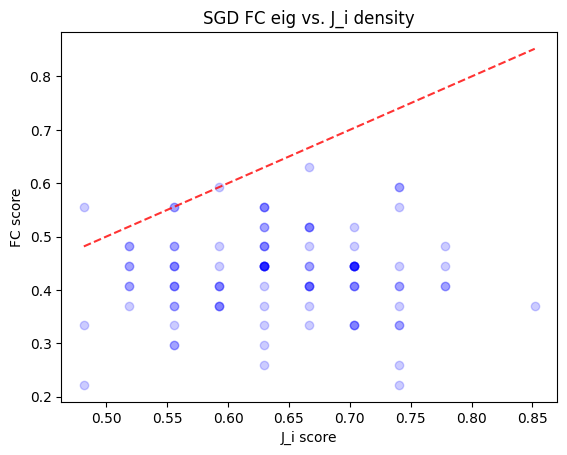

[0.5555555555555556, 0.6666666666666666, 0.6666666666666666, 0.7407407407407407, 0.7777777777777778, 0.5925925925925926, 0.6296296296296297, 0.48148148148148145, 0.5555555555555556, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.7407407407407407, 0.5555555555555556, 0.7037037037037037, 0.7037037037037037, 0.48148148148148145, 0.5185185185185185, 0.5185185185185185, 0.7037037037037037, 0.5925925925925926, 0.5555555555555556, 0.5555555555555556, 0.7037037037037037, 0.6666666666666666, 0.6296296296296297, 0.6666666666666666, 0.5555555555555556, 0.5555555555555556, 0.7777777777777778, 0.7037037037037037, 0.7037037037037037, 0.5555555555555556, 0.6296296296296297, 0.6666666666666666, 0.6666666666666666, 0.7777777777777778, 0.6296296296296297, 0.6296296296296297, 0.7777777777777778, 0.6666666666666666, 0.5555555555555556, 0.6296296296296297, 0.7407407407407407, 0.7037037037037037, 0.5925925925925926, 0.6296296296296297, 0.6296296296296297, 0.7037037037037037, 0.666666666666666

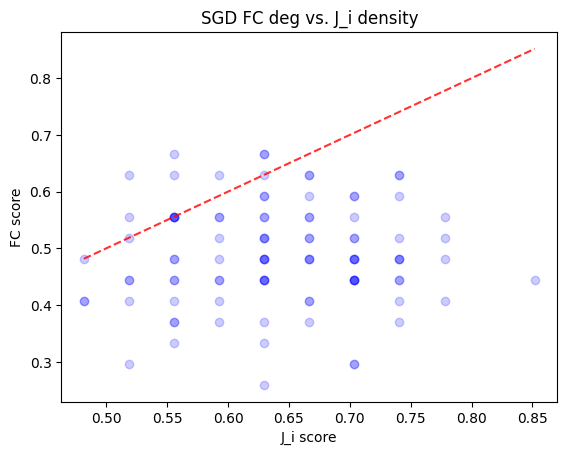

[0.5555555555555556, 0.6666666666666666, 0.6666666666666666, 0.7407407407407407, 0.7777777777777778, 0.5925925925925926, 0.6296296296296297, 0.48148148148148145, 0.5555555555555556, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.7407407407407407, 0.5555555555555556, 0.7037037037037037, 0.7037037037037037, 0.48148148148148145, 0.5185185185185185, 0.5185185185185185, 0.7037037037037037, 0.5925925925925926, 0.5555555555555556, 0.5555555555555556, 0.7037037037037037, 0.6666666666666666, 0.6296296296296297, 0.6666666666666666, 0.5555555555555556, 0.5555555555555556, 0.7777777777777778, 0.7037037037037037, 0.7037037037037037, 0.5555555555555556, 0.6296296296296297, 0.6666666666666666, 0.6666666666666666, 0.7777777777777778, 0.6296296296296297, 0.6296296296296297, 0.7777777777777778, 0.6666666666666666, 0.5555555555555556, 0.6296296296296297, 0.7407407407407407, 0.7037037037037037, 0.5925925925925926, 0.6296296296296297, 0.6296296296296297, 0.7037037037037037, 0.666666666666666

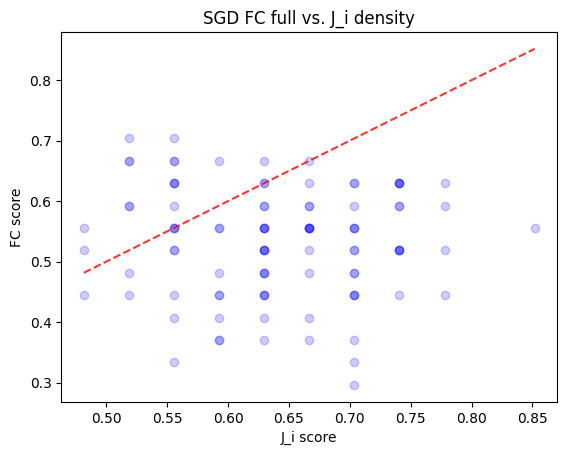

[0.5185185185185185, 0.5555555555555556, 0.6666666666666666, 0.5925925925925926, 0.5555555555555556, 0.5555555555555556, 0.4074074074074074, 0.4444444444444444, 0.4074074074074074, 0.6296296296296297, 0.5925925925925926, 0.5185185185185185, 0.5185185185185185, 0.6296296296296297, 0.5185185185185185, 0.5925925925925926, 0.4074074074074074, 0.6296296296296297, 0.48148148148148145, 0.6666666666666666, 0.4074074074074074, 0.6296296296296297, 0.37037037037037035, 0.7037037037037037, 0.5185185185185185, 0.4444444444444444, 0.4444444444444444, 0.5185185185185185, 0.7037037037037037, 0.4074074074074074, 0.6666666666666666, 0.5185185185185185, 0.5925925925925926, 0.6666666666666666, 0.6666666666666666, 0.5925925925925926, 0.5185185185185185, 0.4074074074074074, 0.6296296296296297, 0.6296296296296297, 0.5555555555555556, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.48148148148148145, 0.5555555555555556, 0.4444444444444444, 0.5185185185185185, 0.5555555555555556, 0.44444444444444

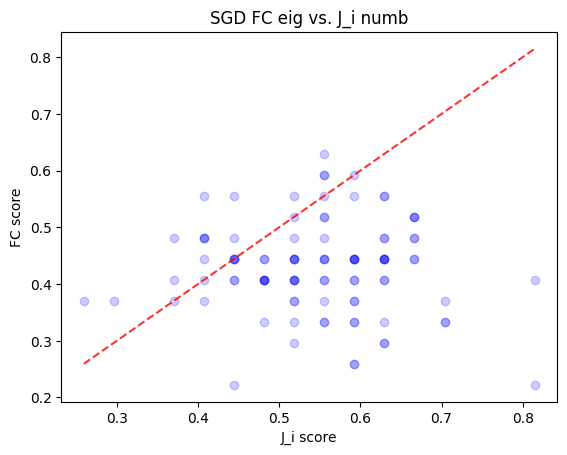

[0.5185185185185185, 0.5555555555555556, 0.6666666666666666, 0.5925925925925926, 0.5555555555555556, 0.5555555555555556, 0.4074074074074074, 0.4444444444444444, 0.4074074074074074, 0.6296296296296297, 0.5925925925925926, 0.5185185185185185, 0.5185185185185185, 0.6296296296296297, 0.5185185185185185, 0.5925925925925926, 0.4074074074074074, 0.6296296296296297, 0.48148148148148145, 0.6666666666666666, 0.4074074074074074, 0.6296296296296297, 0.37037037037037035, 0.7037037037037037, 0.5185185185185185, 0.4444444444444444, 0.4444444444444444, 0.5185185185185185, 0.7037037037037037, 0.4074074074074074, 0.6666666666666666, 0.5185185185185185, 0.5925925925925926, 0.6666666666666666, 0.6666666666666666, 0.5925925925925926, 0.5185185185185185, 0.4074074074074074, 0.6296296296296297, 0.6296296296296297, 0.5555555555555556, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.48148148148148145, 0.5555555555555556, 0.4444444444444444, 0.5185185185185185, 0.5555555555555556, 0.44444444444444

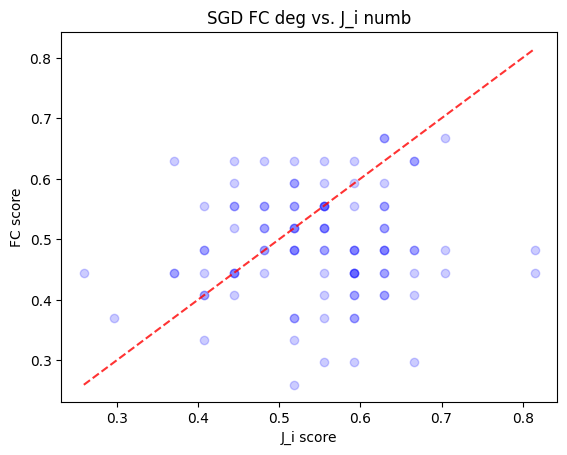

[0.5185185185185185, 0.5555555555555556, 0.6666666666666666, 0.5925925925925926, 0.5555555555555556, 0.5555555555555556, 0.4074074074074074, 0.4444444444444444, 0.4074074074074074, 0.6296296296296297, 0.5925925925925926, 0.5185185185185185, 0.5185185185185185, 0.6296296296296297, 0.5185185185185185, 0.5925925925925926, 0.4074074074074074, 0.6296296296296297, 0.48148148148148145, 0.6666666666666666, 0.4074074074074074, 0.6296296296296297, 0.37037037037037035, 0.7037037037037037, 0.5185185185185185, 0.4444444444444444, 0.4444444444444444, 0.5185185185185185, 0.7037037037037037, 0.4074074074074074, 0.6666666666666666, 0.5185185185185185, 0.5925925925925926, 0.6666666666666666, 0.6666666666666666, 0.5925925925925926, 0.5185185185185185, 0.4074074074074074, 0.6296296296296297, 0.6296296296296297, 0.5555555555555556, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.48148148148148145, 0.5555555555555556, 0.4444444444444444, 0.5185185185185185, 0.5555555555555556, 0.44444444444444

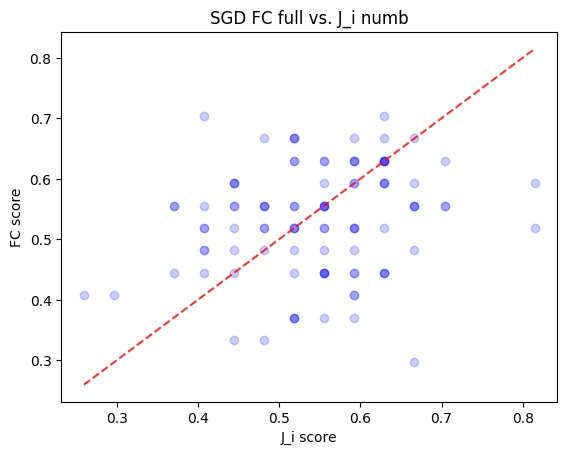

[0.5185185185185185, 0.4074074074074074, 0.48148148148148145, 0.5555555555555556, 0.5925925925925926, 0.6296296296296297, 0.5925925925925926, 0.5925925925925926, 0.5185185185185185, 0.5925925925925926, 0.5185185185185185, 0.7037037037037037, 0.5185185185185185, 0.5555555555555556, 0.2962962962962963, 0.37037037037037035, 0.5185185185185185, 0.37037037037037035, 0.5185185185185185, 0.6296296296296297, 0.48148148148148145, 0.4074074074074074, 0.48148148148148145, 0.5185185185185185, 0.5555555555555556, 0.48148148148148145, 0.48148148148148145, 0.5925925925925926, 0.5185185185185185, 0.37037037037037035, 0.5555555555555556, 0.5185185185185185, 0.5925925925925926, 0.5555555555555556, 0.37037037037037035, 0.48148148148148145, 0.48148148148148145, 0.5925925925925926, 0.5925925925925926, 0.4444444444444444, 0.5555555555555556, 0.5185185185185185, 0.6296296296296297, 0.37037037037037035, 0.4444444444444444, 0.6296296296296297, 0.5555555555555556, 0.4074074074074074, 0.5185185185185185, 0.62962

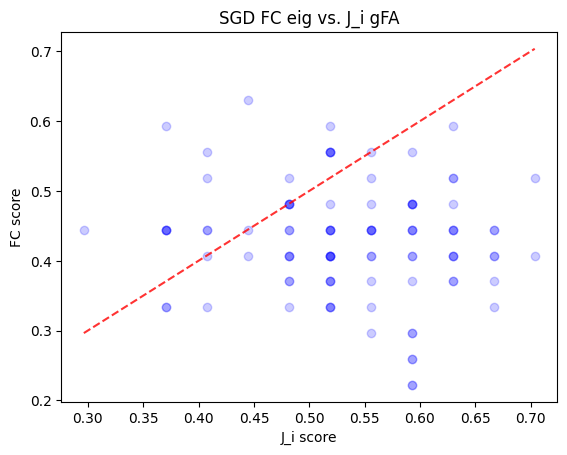

[0.5185185185185185, 0.4074074074074074, 0.48148148148148145, 0.5555555555555556, 0.5925925925925926, 0.6296296296296297, 0.5925925925925926, 0.5925925925925926, 0.5185185185185185, 0.5925925925925926, 0.5185185185185185, 0.7037037037037037, 0.5185185185185185, 0.5555555555555556, 0.2962962962962963, 0.37037037037037035, 0.5185185185185185, 0.37037037037037035, 0.5185185185185185, 0.6296296296296297, 0.48148148148148145, 0.4074074074074074, 0.48148148148148145, 0.5185185185185185, 0.5555555555555556, 0.48148148148148145, 0.48148148148148145, 0.5925925925925926, 0.5185185185185185, 0.37037037037037035, 0.5555555555555556, 0.5185185185185185, 0.5925925925925926, 0.5555555555555556, 0.37037037037037035, 0.48148148148148145, 0.48148148148148145, 0.5925925925925926, 0.5925925925925926, 0.4444444444444444, 0.5555555555555556, 0.5185185185185185, 0.6296296296296297, 0.37037037037037035, 0.4444444444444444, 0.6296296296296297, 0.5555555555555556, 0.4074074074074074, 0.5185185185185185, 0.62962

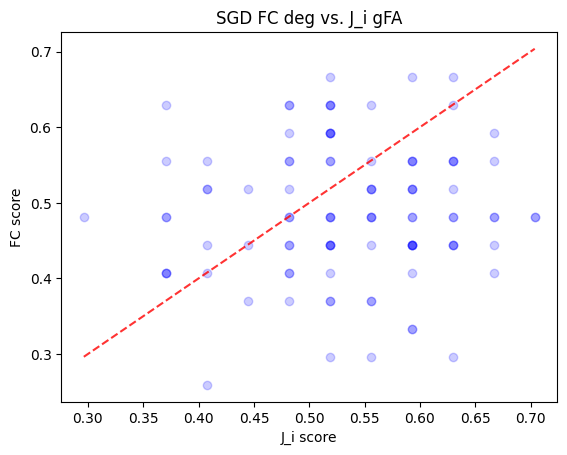

[0.5185185185185185, 0.4074074074074074, 0.48148148148148145, 0.5555555555555556, 0.5925925925925926, 0.6296296296296297, 0.5925925925925926, 0.5925925925925926, 0.5185185185185185, 0.5925925925925926, 0.5185185185185185, 0.7037037037037037, 0.5185185185185185, 0.5555555555555556, 0.2962962962962963, 0.37037037037037035, 0.5185185185185185, 0.37037037037037035, 0.5185185185185185, 0.6296296296296297, 0.48148148148148145, 0.4074074074074074, 0.48148148148148145, 0.5185185185185185, 0.5555555555555556, 0.48148148148148145, 0.48148148148148145, 0.5925925925925926, 0.5185185185185185, 0.37037037037037035, 0.5555555555555556, 0.5185185185185185, 0.5925925925925926, 0.5555555555555556, 0.37037037037037035, 0.48148148148148145, 0.48148148148148145, 0.5925925925925926, 0.5925925925925926, 0.4444444444444444, 0.5555555555555556, 0.5185185185185185, 0.6296296296296297, 0.37037037037037035, 0.4444444444444444, 0.6296296296296297, 0.5555555555555556, 0.4074074074074074, 0.5185185185185185, 0.62962

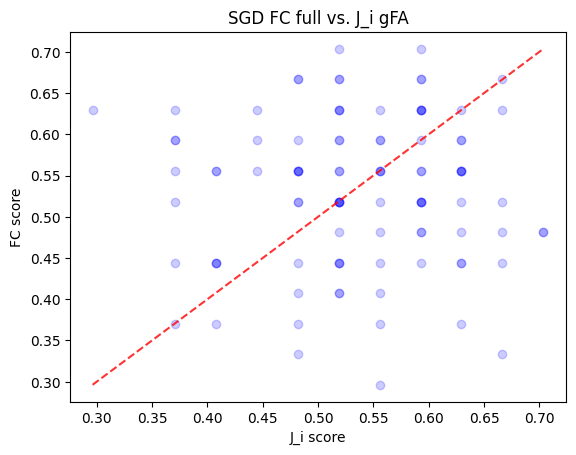

[0.6666666666666666, 0.5185185185185185, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.5925925925925926, 0.7407407407407407, 0.5925925925925926, 0.5185185185185185, 0.6296296296296297, 0.6296296296296297, 0.5925925925925926, 0.7037037037037037, 0.5555555555555556, 0.7037037037037037, 0.5185185185185185, 0.7037037037037037, 0.4444444444444444, 0.5925925925925926, 0.7407407407407407, 0.6666666666666666, 0.48148148148148145, 0.4074074074074074, 0.6666666666666666, 0.5555555555555556, 0.5185185185185185, 0.5185185185185185, 0.48148148148148145, 0.5555555555555556, 0.5925925925925926, 0.4444444444444444, 0.4444444444444444, 0.5925925925925926, 0.5925925925925926, 0.6296296296296297, 0.5925925925925926, 0.48148148148148145, 0.7037037037037037, 0.5925925925925926, 0.6666666666666666, 0.4444444444444444, 0.48148148148148145, 0.6296296296296297, 0.7407407407407407, 0.5185185185185185, 0.5925925925925926, 0.5925925925925926, 0.48148148148148145, 0.6666666666666666, 0.703703703703

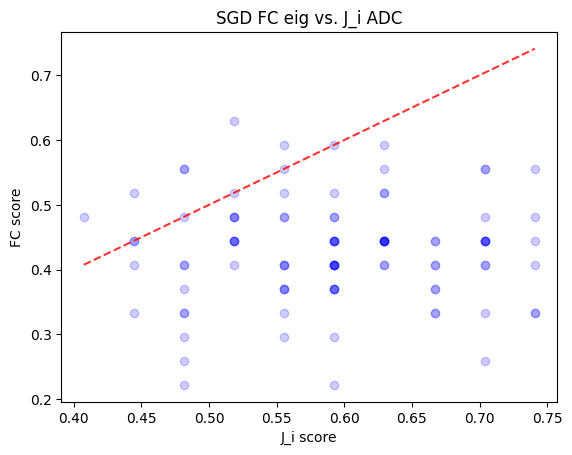

[0.6666666666666666, 0.5185185185185185, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.5925925925925926, 0.7407407407407407, 0.5925925925925926, 0.5185185185185185, 0.6296296296296297, 0.6296296296296297, 0.5925925925925926, 0.7037037037037037, 0.5555555555555556, 0.7037037037037037, 0.5185185185185185, 0.7037037037037037, 0.4444444444444444, 0.5925925925925926, 0.7407407407407407, 0.6666666666666666, 0.48148148148148145, 0.4074074074074074, 0.6666666666666666, 0.5555555555555556, 0.5185185185185185, 0.5185185185185185, 0.48148148148148145, 0.5555555555555556, 0.5925925925925926, 0.4444444444444444, 0.4444444444444444, 0.5925925925925926, 0.5925925925925926, 0.6296296296296297, 0.5925925925925926, 0.48148148148148145, 0.7037037037037037, 0.5925925925925926, 0.6666666666666666, 0.4444444444444444, 0.48148148148148145, 0.6296296296296297, 0.7407407407407407, 0.5185185185185185, 0.5925925925925926, 0.5925925925925926, 0.48148148148148145, 0.6666666666666666, 0.703703703703

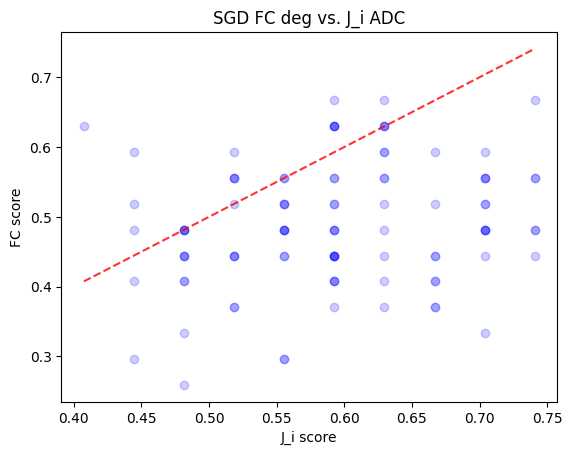

[0.6666666666666666, 0.5185185185185185, 0.6296296296296297, 0.6296296296296297, 0.6296296296296297, 0.5925925925925926, 0.7407407407407407, 0.5925925925925926, 0.5185185185185185, 0.6296296296296297, 0.6296296296296297, 0.5925925925925926, 0.7037037037037037, 0.5555555555555556, 0.7037037037037037, 0.5185185185185185, 0.7037037037037037, 0.4444444444444444, 0.5925925925925926, 0.7407407407407407, 0.6666666666666666, 0.48148148148148145, 0.4074074074074074, 0.6666666666666666, 0.5555555555555556, 0.5185185185185185, 0.5185185185185185, 0.48148148148148145, 0.5555555555555556, 0.5925925925925926, 0.4444444444444444, 0.4444444444444444, 0.5925925925925926, 0.5925925925925926, 0.6296296296296297, 0.5925925925925926, 0.48148148148148145, 0.7037037037037037, 0.5925925925925926, 0.6666666666666666, 0.4444444444444444, 0.48148148148148145, 0.6296296296296297, 0.7407407407407407, 0.5185185185185185, 0.5925925925925926, 0.5925925925925926, 0.48148148148148145, 0.6666666666666666, 0.703703703703

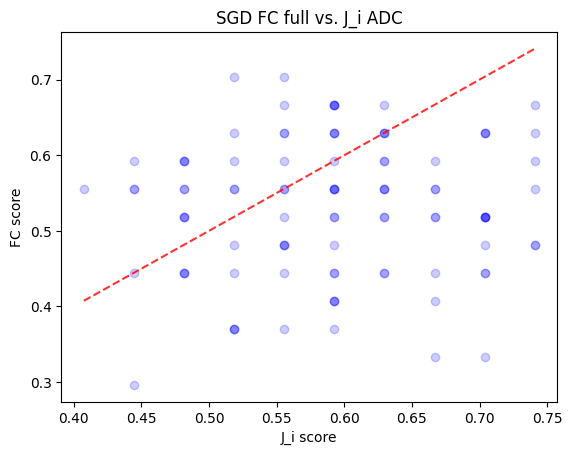

In [14]:
# scatter plots to compare 

import matplotlib.pyplot as plt

SC_scores = {
    'deg': 'SC_deg',
    'eig': 'SC_eig'
}

for metric in metrics_all:    
    for weight in weights:
        x = score_all_SGD['J_i'][metric]
        y = FC_score_SGD[weight]
        print(x)
        print(y)
        plt.plot([min(x), max(x)], [min(x), max(x)], color='red', alpha=0.8, linestyle='--', label='y = x')
        # Create scatter plot
        plt.scatter(x, y, color='blue', alpha=0.2)

        # Add labels and title
        plt.xlabel('J_i score')
        plt.ylabel('FC score')
        plt.title(f'SGD FC {weight} vs. J_i {metric}')
        plt.savefig(f'SGD FC_{weight}_vs_J_i_{metric}.pdf')


        plt.show()

In [ ]:
# visualization using violin plots 
list1 = ['eig', 'deg', 'full']
list2 = ['J_i', 'wFFI', 'wLRE']
for loss_id in losses: 
    for key2 in list2:
        for key1 in list1:
            rows_SGD = []
            for metric in metrics_all:
                for score in score_all_SGD[key2][metric][loss_id]:
                    rows_SGD.append({'Metric': metric, 'Test Score': score, 'Source': key2})
        
                for score in FC_score_SGD[key1][loss_id]:
                    rows_SGD.append({'Metric': metric, 'Test Score': score, 'Source': f" FC {weight}"})
            df_plot_SGD = pd.DataFrame(rows_SGD)
                    
            plt.figure()
            sns.violinplot(data=df_plot_SGD, x='Metric', y='Test Score', hue='Source', split=True, gap=.1, inner="quart")
            plt.title(f"SGD classifier: {key2} , FC {key1}, {loss_id}")
            plt.show()
        
        
    list3 = ['wFFI', 'J_i', 'wLRE'] 
    for key in list3: 
        rows_FC_SC_SGD = []     
        for metric in metrics_all:
            for score in score_all_SGD[key][metric][loss_id]:
                rows_FC_SC_SGD.append({'Metric': metric, 'Test Score': score, 'Source': key})
            for score in score_all_SGD['FC_SC'][metric][loss_id]:
                rows_FC_SC_SGD.append({'Metric': metric, 'Test Score': score, 'Source': 'FC_SC'})
        df_plot_FC_SC_SGD = pd.DataFrame(rows_FC_SC_SGD)
                        
        plt.figure()
        sns.violinplot(data=df_plot_FC_SC_SGD, x='Metric', y='Test Score', hue='Source', split=True, gap=.1, inner="quart")
        plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='chance level')
        plt.axhline(y=0.98, color='black', linestyle='--', linewidth=1, label='benchmark')
        plt.title(f"SGD classifier {key} vs. FC_SC {loss_id}")
        # plt.savefig(f'SGD_violinplot_{key}_FC_SC_{loss_id}.pdf')
        plt.show()

In [ ]:
# visualization violin plot across different losses 

for metric in metrics_all: 
    for key2 in list2:
    # for key1 in list1:
        rows_SGD = []
        for loss_id in losses:
            for score in score_all_SGD[key2][metric][loss_id]:
                rows_SGD.append({'Loss function': loss_id, 'Test Score': score, 'Source': key2})
    
            for score in score_all_SGD['FC_SC'][metric][loss_id]:
                rows_SGD.append({'Loss function': loss_id, 'Test Score': score, 'Source': f" FC_SC"})
        df_plot_SGD = pd.DataFrame(rows_SGD)
                
        plt.figure()
        sns.violinplot(data=df_plot_SGD, x='Loss function', y='Test Score', hue='Source', split=True, gap=.1, inner="quart")
        plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='chance level')
        plt.axhline(y=0.98, color='black', linestyle='--', linewidth=1, label='benchmark')
        plt.title(f"SGD classifier: {key2} , FC_SC, {metric}")
        plt.savefig(f"SGD classifier_loss_function_{key2}_{metric}.pdf")
        plt.show()